### 1.Introdução
Este notebook tem como objetivo realizar o tratamento dos dados fornecidos pela instituição EAFIT, a fim de limpar, organizar e transformá-los em um formato mais adequado para análise. O foco é preparar a base de dados para o treinamento e teste de um modelo preditivo, cujo propósito é identificar, já a partir da 5ª semana de aulas, quais alunos apresentam maior probabilidade de reprovação. 

### 2. Configuração de Ambiente

#### 2.1 Importação
Para começar uma análise e manipulação dos dados, é essencial importar todos os dados que foram usados para alcançar nosso objetivo 

In [80]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots
import plotly.io as pio 
pio.renderers.default = "vscode"

# Caminhos de entrada
XLSX1_PATH = "../Datos_Anonimo_20231_v2.xlsx"  # 1º semestre
XLSX2_PATH = "../Datos_Anonimo_20232_v2.xlsx"  # 2º semestre
SHEET_INDEX = 1  # segunda aba

#### 2.2 Tradução dos dados para nossa língua
Com intuito de obter a maior entendimento e facilidade para nossa equipe, traduzimos os dados para maior entendimento e facilidade em tratá-los. 

In [81]:
# Renomeação de colunas ES -> PT (sem acentos nos nomes de colunas para evitar problemas)
rename_map = {
    "Periodo": "Periodo",
    "Grupo": "Grupo",
    "Horario": "Horario",
    "Tipo_Documento": "Tipo_Documento",
    "Edad": "Idade",
    "Genero": "Genero",
    "STEM": "STEM",
    "MejoraNotaQuices": "MelhoraNotaQuizzes",
    "Calificación_Oficial": "Nota_Oficial",
    "Aprobo": "Aprovou",
    "Nombre_Programa_Academico": "Nome_Programa_Academico",
    "Nombre_Programa_Académico": "Nome_Programa_Academico",
    "Proyecto_Parte1": "Projeto_Parte1",
    "Proyecto_Parte2": "Projeto_Parte2",
    "Talleres": "Oficinas",
    "Quices": "Quizzes",
    "CalcNotaQuiz": "CalcNotaQuiz",
    "Parcial_1": "Parcial_1",
    "Parcial_2": "Parcial_2",
    "Quiz1": "Quiz1",
    "Quiz2": "Quiz2",
    "Quiz3": "Quiz3",
    "Quiz4": "Quiz4",
    "Quiz5": "Quiz5",
    "Quiz6": "Quiz6",
    "Quiz7": "Quiz7",
    "Quiz8": "Quiz8",
    "Cuánto mejora?": "Quanto_Melhora",
    "Cuanto mejora?": "Quanto_Melhora",
}
# N mínimo prático para o dataset atual: 8 (fecha/tiempo 1..8)
for i in range(1, 9):
    rename_map[f"Fecha_Quiz{i}"] = f"Data_Quiz{i}"
    rename_map[f"TiempoQ{i}"] = f"TempoQ{i}"

MAPA_PROGRAMAS = {
    "COMUNICACIÓN SOCIAL": "Comunicacao Social",
    "DERECHO": "Direito",
    "INGENIERÍA CIVIL": "Engenharia Civil",
    "ADMINISTRACIÓN DE NEGOCIOS": "Administracao de Negocios",
    "INGENIERÍA DE DISEÑO DE PRODUCTO": "Engenharia de Design de Produto",
    "MERCADEO": "Marketing",
    "PSICOLOGÍA": "Psicologia",
    "INGENIERÍA FÍSICA": "Engenharia Fisica",
    "NEGOCIOS INTERNACIONALES": "Negocios Internacionais",
    "BIOLOGÍA": "Biologia",
    "CIENCIAS POLÍTICAS": "Ciencias Politicas",
    "ECONOMÍA": "Economia",
    "CONTADURÍA PÚBLICA": "Contabilidade Publica",
    "MÚSICA": "Musica",
    "LITERATURA": "Literatura",
    "INGENIERÍA DE PROCESOS": "Engenharia de Processos",
    "CONVENIO MOVILIDAD PREGRADO (CONVENIOS - MOVILIDAD NACIONAL - ASISTENTES PREGRADO)":
        "Convenio Mobilidade Graduacao (Convenios - Mobilidade Nacional - Assistentes Graduacao)",
}
MAPA_APROV = {"Aprobó": "Aprovou", "Reprobó": "Reprovou", "Aprobo": "Aprovou", "Reprobo": "Reprovou"}
MAPA_IDADE = {"Mayor": "Maior", "Menor": "Menor"}
MAPA_GENERO = {"femenino": "Feminino", "masculino": "Masculino", "Femenino": "Feminino", "Masculino": "Masculino"}

# Padronização de STEM para PT: "Sim" / "No"
MAPA_STEM = {
    "Sí": "Sim", "SÍ": "Sim", "si": "Sim", "SIM": "Sim", "Sim": "Sim",
    "YES": "Sim", "Yes": "Sim", "TRUE": "Sim", "True": "Sim", "1": "Sim",
    "No": "No", "NO": "No", "Nao": "No", "Não": "No", "nao": "No",
    "FALSE": "No", "False": "No", "0": "No",
}

ERROR_TOKENS = {
    "#ERROR!", "#DIV/0!", "#N/A", "#NAME?", "#NULL!", "#NUM!", "#VALUE!", "#REF!",
    "N/D", "N/A", "NA", "NaN", "nan", "None", "NONE"
}

#### 2.3 Padronização e Tratamento
Nesta célula está o código responsável por Tratamento de erros e padronização, será retirado linhas com dados faltando, uniformizando dados diferentes se referindo a mesma coisa; Tratamento de tempo, uniformizando o tipo de tempo que queremos usar, ou seja, transformando tudo em segundos; Filtragem de alunos, retira alunos que não fizeram nenhum teste; Detecção e tratamento de outliers e Detecção e tratamento de outliers. Tudo isso para que seja adequado não só para a melhor análise e retirada de insights, quanto para o modelo não alucinar.

In [82]:
# Limpar células com error
def replace_excel_errors(df, cols=None):
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include="object").columns.tolist()
    for c in cols:
        if c in df.columns:
            df[c] = df[c].replace(list(ERROR_TOKENS), np.nan)
    return df

# Padronização do dataframe
def padroniza_df(df):
    df = df.copy().rename(columns=rename_map)
    df = replace_excel_errors(df)
    if "Nome_Programa_Academico" in df.columns:
        df["Nome_Programa_Academico"] = (
            df["Nome_Programa_Academico"].astype(str).str.strip().replace(MAPA_PROGRAMAS, regex=False)
        )
    if "Aprovou" in df.columns:
        df["Aprovou"] = df["Aprovou"].astype(str).str.strip().replace(MAPA_APROV, regex=False)
    if "Idade" in df.columns:
        df["Idade"] = df["Idade"].astype(str).str.strip().replace(MAPA_IDADE, regex=False)
    if "Genero" in df.columns:
        df["Genero"] = df["Genero"].astype(str).str.strip().replace(MAPA_GENERO, regex=False)
    if "STEM" in df.columns:
        mask = df["STEM"].notna()
        if mask.any():
            df.loc[mask, "STEM"] = df.loc[mask, "STEM"].astype(str).str.strip().replace(MAPA_STEM, regex=False)
    return df

# Regex para parse de tempo (ex.: "2 minutos 10 segundos")
_PATTERN_TEMPO = re.compile(
    r"^\s*(?:(\d+)\s*minuto(?:s)?)?\s*(?:(\d+)\s*segundo(?:s)?)?\s*$",
    re.IGNORECASE
)

# Normalização dos tempos
def parse_to_seconds(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)) and not isinstance(val, bool):
        try:
            return int(val)
        except Exception:
            return np.nan
    if isinstance(val, str):
        s = val.strip()
        try:
            return int(float(s))
        except Exception:
            pass
        s_norm = s.replace(" e ", " ").replace(",", " ")
        m = _PATTERN_TEMPO.match(s_norm)
        if m:
            mins, secs = m.group(1), m.group(2)
            total = (int(mins) * 60 if mins else 0) + (int(secs) if secs else 0)
            return total if (mins or secs) else np.nan
        if ":" in s_norm:
            parts = [p.strip() for p in s_norm.split(":")]
            if len(parts) == 2 and all(p.isdigit() for p in parts):
                mm, ss = map(int, parts)
                return mm * 60 + ss
            if len(parts) == 3 and all(p.isdigit() for p in parts):
                hh, mm, ss = map(int, parts)
                return hh * 3600 + mm * 60 + ss
    return np.nan

# Padroniza as colunas de tempo
def converte_colunas_tempo(df):
    df = df.copy()
    cols_tempo = [c for c in df.columns if re.match(r"^(TempoQ|TiempoQ)\d+$", c)]
    for col in cols_tempo:
        df[col] = df[col].apply(parse_to_seconds)
    return df

# Remove os alunos faltantes
def filtra_alunos_presentes(df):
    df = df.copy()
    cols_data = [c for c in df.columns if re.match(r"^(Data_Quiz|Fecha_Quiz)\d+$", c)]
    if not cols_data:
        return df
    df_filtrado = df.dropna(subset=cols_data, how="all")
    df_filtrado = df_filtrado.drop(columns=cols_data)
    return df_filtrado

def remove_outliers(df, n_cols_per_row=3):
    df_numeric = df.select_dtypes(include=["number"])
    df_numeric = df_numeric.drop(columns=["Grupo"], errors="ignore")  # evita erro se não existir

    n_cols = len(df_numeric.columns)
    n_rows = math.ceil(n_cols / n_cols_per_row)

    # Boxplots originais
    fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(6*n_cols_per_row, 4*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(df_numeric.columns):
        sns.boxplot(x=df_numeric[col], ax=axes[i])
        axes[i].set_title(f"Boxplot - {col}")
    # remover eixos vazios
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    # Normalizar os outliers (clip)
    for col in df_numeric.columns:
        Q1 = df_numeric[col].quantile(0.25)
        Q3 = df_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_numeric[col] = df_numeric[col].clip(lower, upper)

    # Boxplots limpos
    fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(6*n_cols_per_row, 4*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(df_numeric.columns):
        sns.boxplot(x=df_numeric[col], ax=axes[i])
        axes[i].set_title(f"Boxplot cleaned - {col}")
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

    return df_numeric

def fit_onehot_encoder(df_cat, cat_cols):
    cat_cols_exist = [c for c in cat_cols if c in df_cat.columns]
    if not cat_cols_exist:
        return {"type": "none", "encoder": None, "columns": [], "cat_cols": []}
    X_fit = replace_excel_errors(df_cat[cat_cols_exist].copy(), cols=cat_cols_exist)
    X_fit = X_fit.fillna("MISSING").astype(str)
    try:
        from sklearn.preprocessing import OneHotEncoder
        try:
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        except TypeError:
            enc = OneHotEncoder(sparse=False, handle_unknown="ignore")
        enc.fit(X_fit)
        cols = list(enc.get_feature_names_out(cat_cols_exist))
        return {"type": "sklearn", "encoder": enc, "columns": cols, "cat_cols": cat_cols_exist}
    except Exception:
        dummies = pd.get_dummies(X_fit, prefix=cat_cols_exist, dummy_na=False)
        cols = dummies.columns.tolist()
        return {"type": "pandas", "encoder": cols, "columns": cols, "cat_cols": cat_cols_exist}

def aplica_onehot(df, encoder_info):
    df = df.copy()
    if encoder_info["type"] == "none":
        return df
    cat_cols_exist = encoder_info["cat_cols"]
    X = replace_excel_errors(df[cat_cols_exist].copy(), cols=cat_cols_exist).fillna("MISSING").astype(str)
    if encoder_info["type"] == "sklearn":
        arr = encoder_info["encoder"].transform(X)
        encoded_df = pd.DataFrame(arr, columns=encoder_info["columns"], index=df.index)
        out = pd.concat([df.drop(columns=cat_cols_exist), encoded_df], axis=1)
    else:
        dummies_df = pd.get_dummies(X, prefix=cat_cols_exist, dummy_na=False)
        all_cols = encoder_info["columns"]
        for c in all_cols:
            if c not in dummies_df.columns:
                dummies_df[c] = 0
        dummies_df = dummies_df[all_cols]
        out = pd.concat([df.drop(columns=cat_cols_exist), dummies_df], axis=1)
    bad_cols = [c for c in out.columns if "#ERROR!" in c]
    if bad_cols:
        out = out.drop(columns=bad_cols)
    return out

def estatisticas_basicas(df):
    possiveis = [f"Quiz{i}" for i in range(1, 13)] + [f"TempoQ{i}" for i in range(1, 13)]
    possiveis += ["Oficinas", "Parcial_1", "Parcial_2", "CalcNotaQuiz", "Nota_Oficial"]
    cols_exist = [c for c in possiveis if c in df.columns]
    if not cols_exist:
        return pd.DataFrame()
    num_cols = [c for c in cols_exist if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        return pd.DataFrame()
    return df[num_cols].describe().copy()

### 3. Análise dos dados e criação de gráficos

#### 3.1 Pipeline de processamento
Com todas as funções dos tratamentos feitos, será feito o carregamento dos dois arquivos, a aplicações das funções feitas nas seções 2, junção dos dois arquivos em um e gráficos com outliers com intuito de retirá-los para não danificar o funcionamento do nosso modelo.

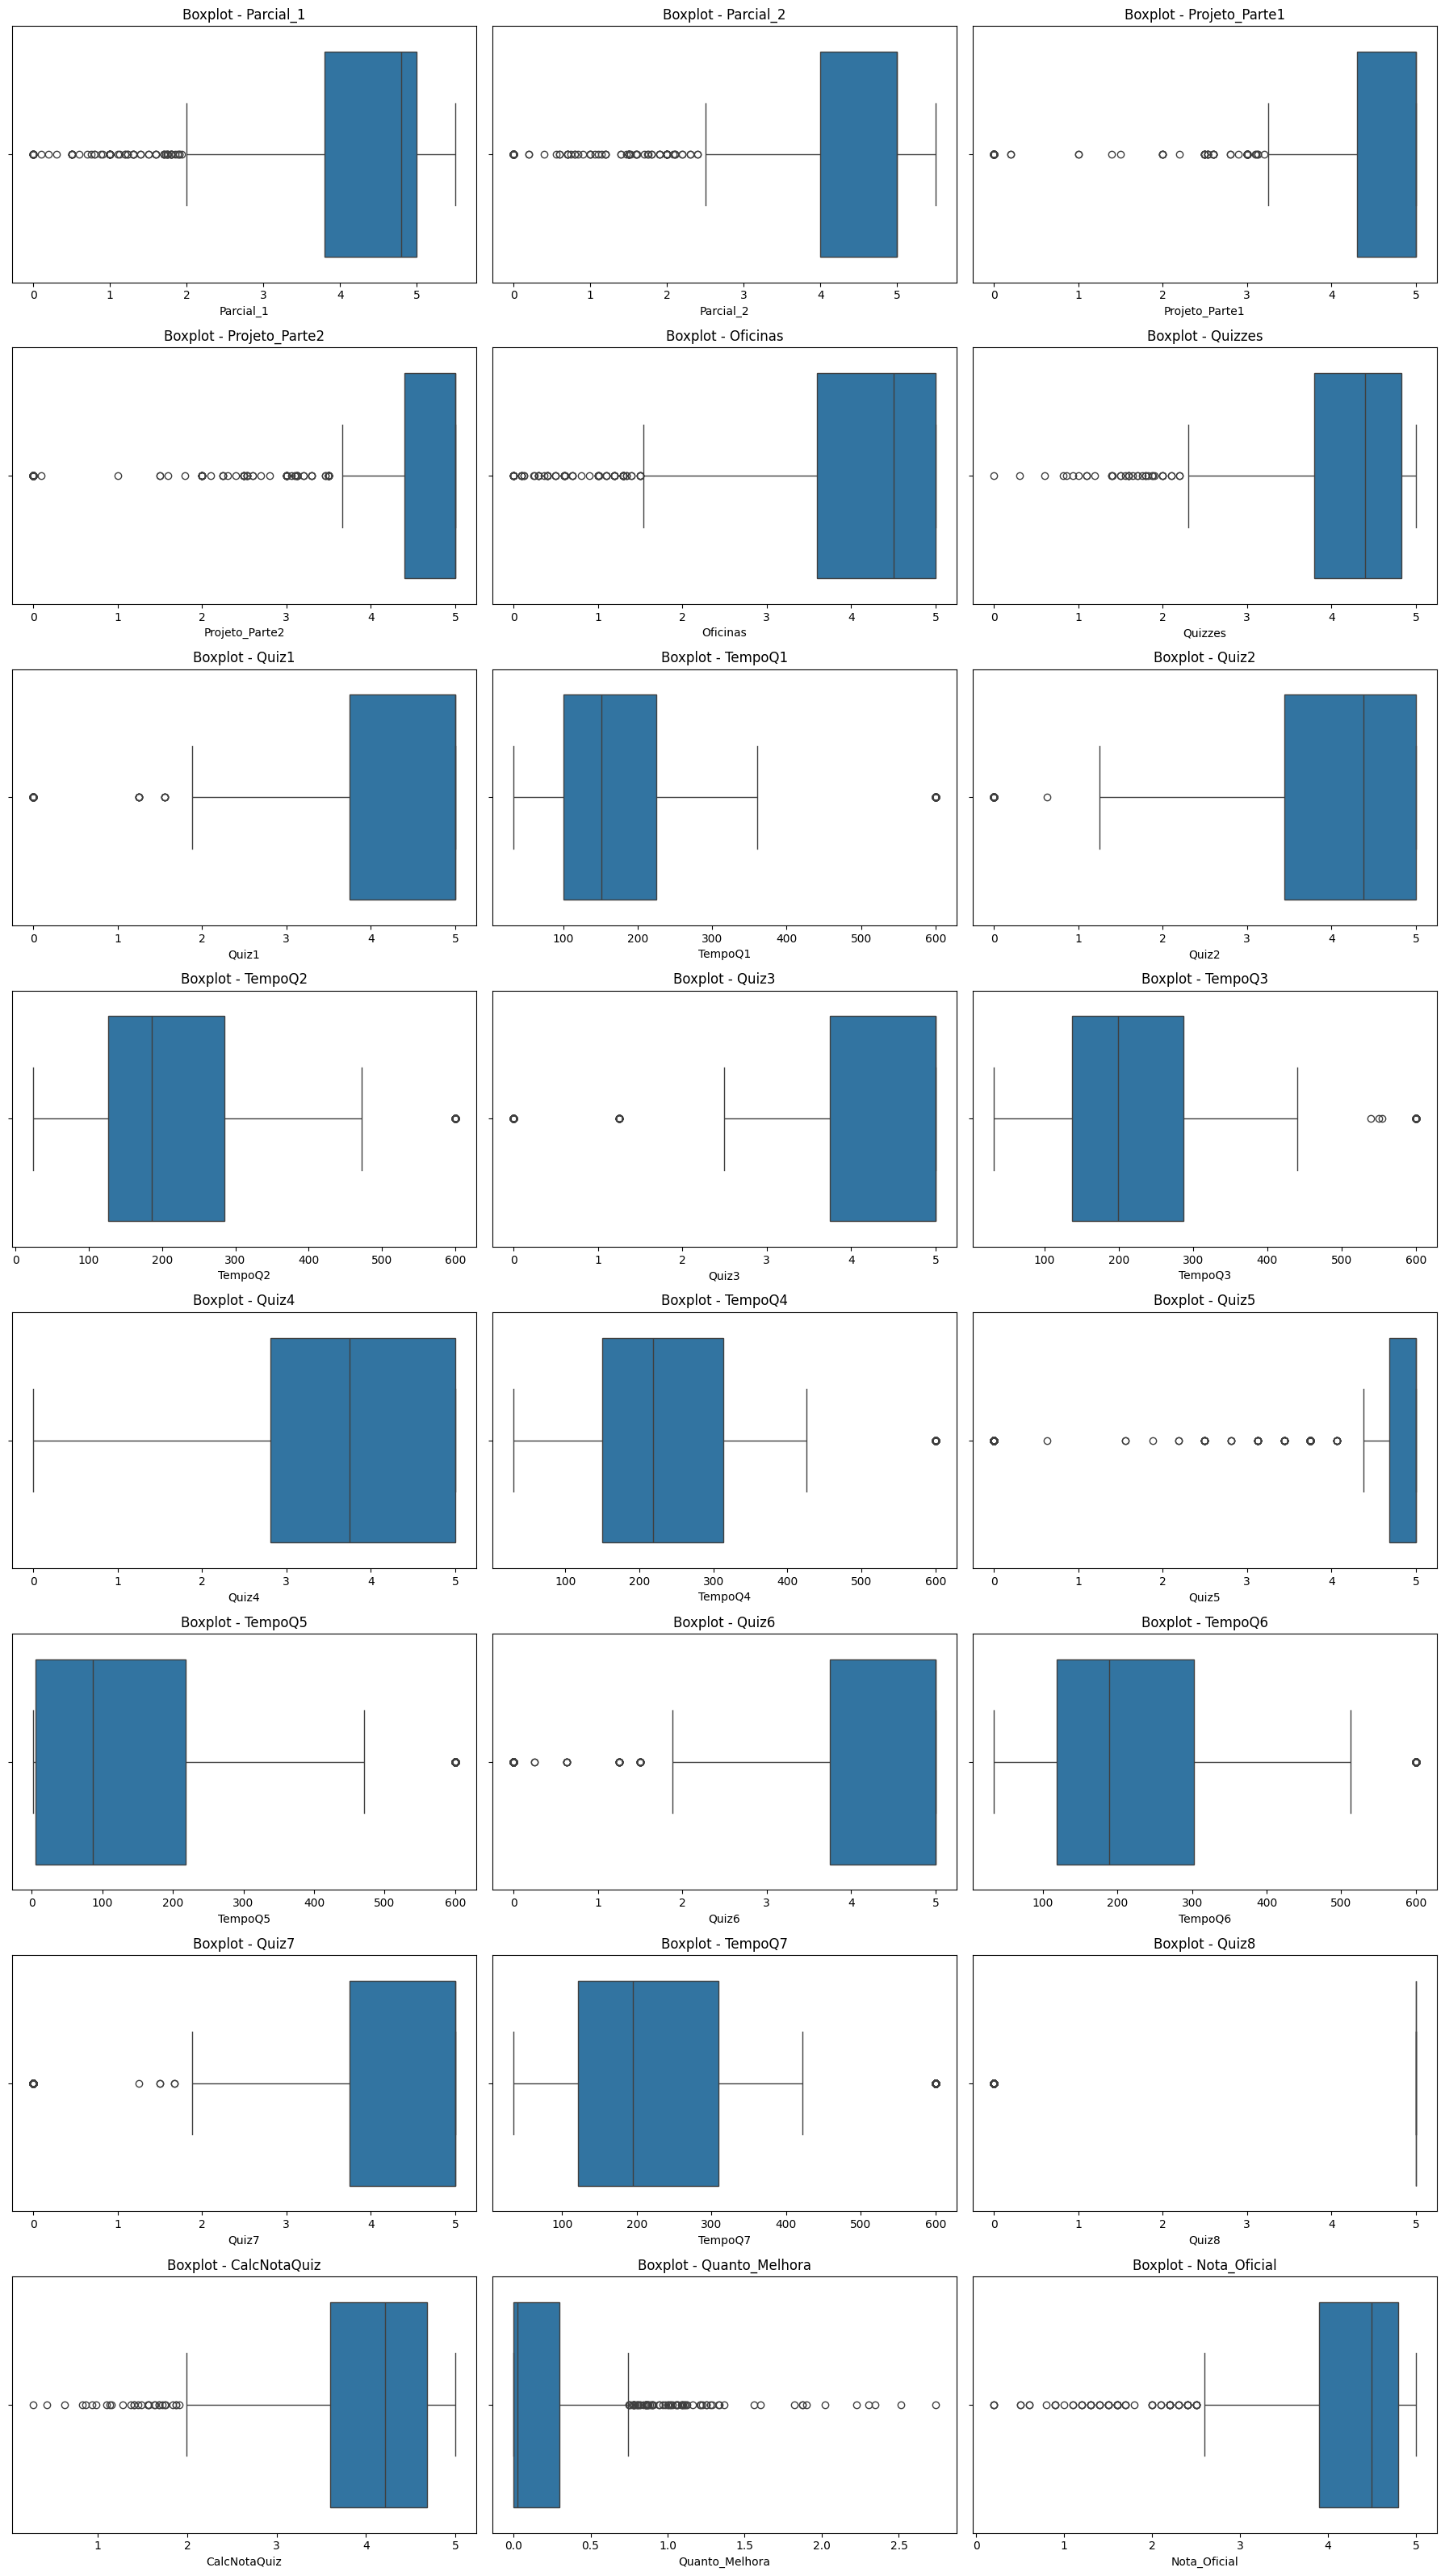

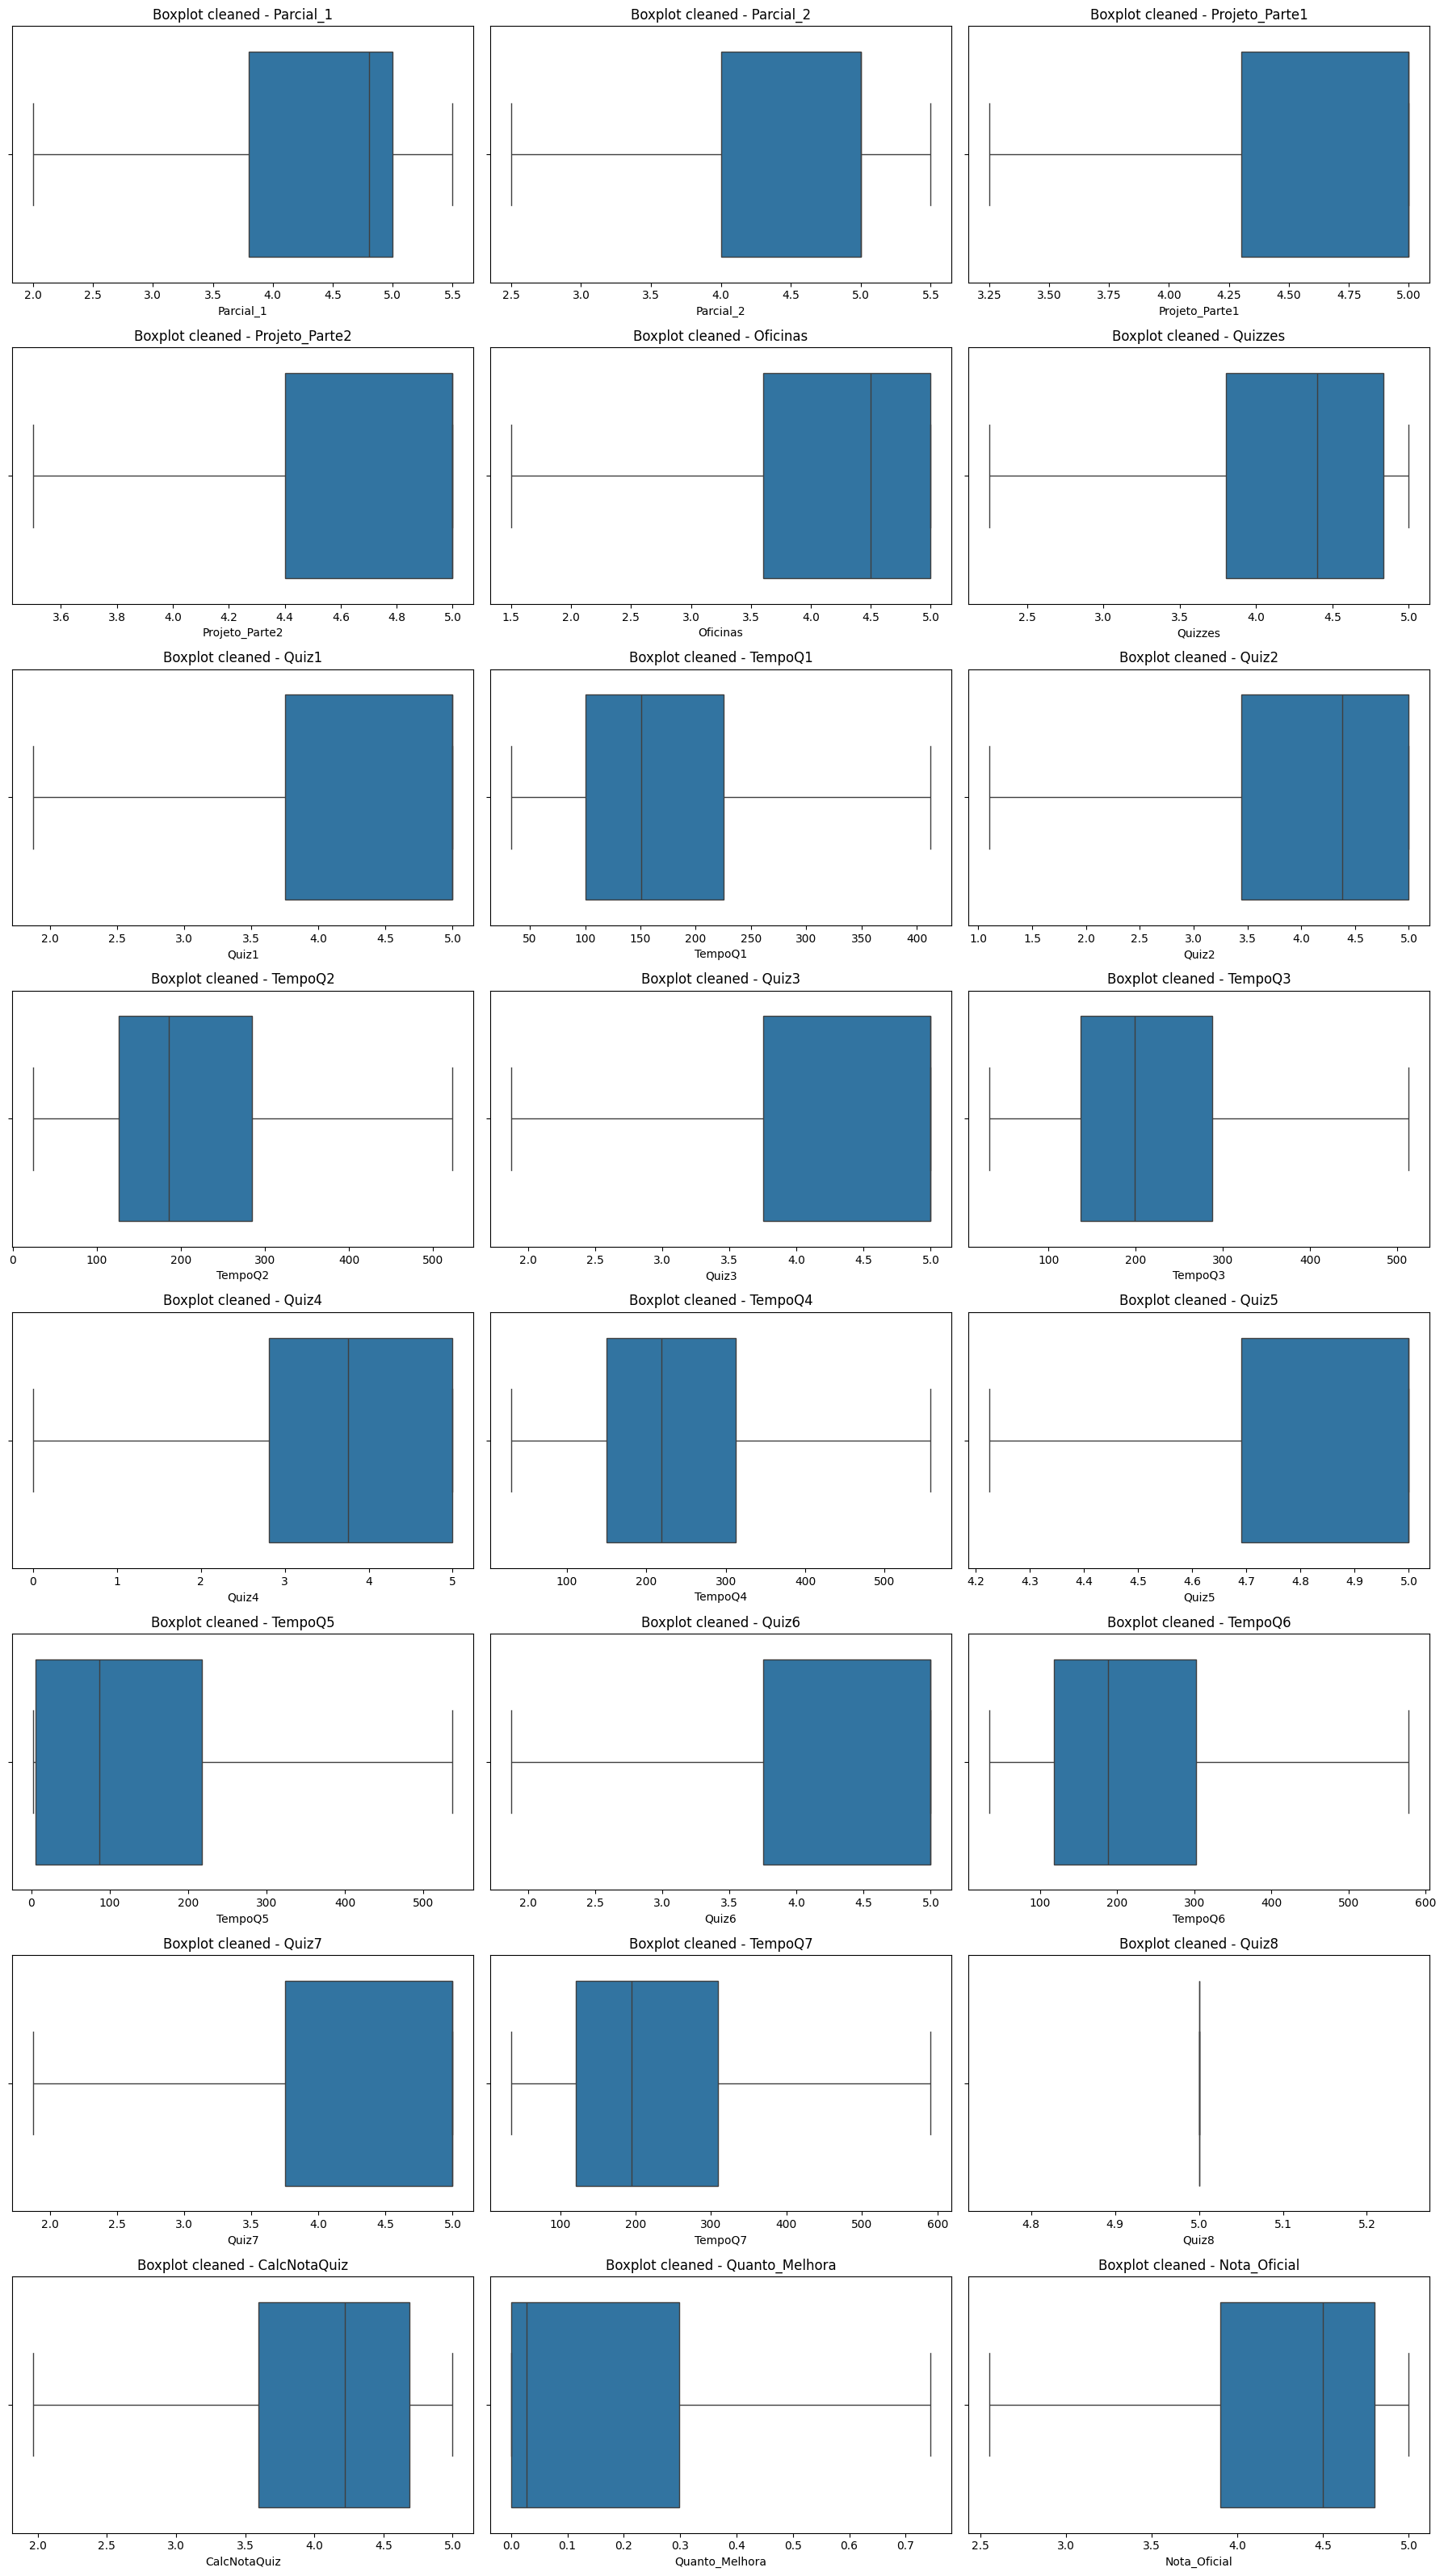

df_consolidado: (1375, 34)
df_onehot: (1375, 42)


In [83]:
# 1) Carregar Excel
df1_raw = pd.read_excel(XLSX1_PATH, sheet_name=SHEET_INDEX)
df2_raw = pd.read_excel(XLSX2_PATH, sheet_name=SHEET_INDEX)

# 2) Padronizar valores/nomes
df1 = padroniza_df(df1_raw)
df2 = padroniza_df(df2_raw)

# 3) Converter tempos para segundos
df1 = converte_colunas_tempo(df1)
df2 = converte_colunas_tempo(df2)

# 4) Filtrar apenas alunos com algum quiz e remover colunas de datas
df1_presentes = filtra_alunos_presentes(df1)
df2_presentes = filtra_alunos_presentes(df2)

# 5) Concatenar
df_consolidado = pd.concat([df1_presentes, df2_presentes], ignore_index=True)

# 5.1) Limpar outliers das colunas numéricas
df_numeric_clean = remove_outliers(df_consolidado)  # faz clip nos outliers
# Substituir as colunas numéricas no df_consolidado
df_consolidado[df_numeric_clean.columns] = df_numeric_clean

# 6) Remover linhas com STEM ausente, replicando lógica original
if "STEM" in df_consolidado.columns:
    df_consolidado = df_consolidado.dropna(subset=["STEM"])

# 7) One-Hot
cat_cols = ["Tipo_Documento", "Idade", "Genero", "STEM", "MelhoraNotaQuizzes", "Aprovou"]
encoder_info = fit_onehot_encoder(df_consolidado, cat_cols)
df_onehot = aplica_onehot(df_consolidado, encoder_info)

# 8) Estatísticas
tabela_stats = estatisticas_basicas(df_consolidado)

# Amostras
print("df_consolidado:", df_consolidado.shape)
print("df_onehot:", df_onehot.shape)


#### 3.1 Gráficos de correlação
O intuito dessa célula é identificar quais dados tem relação que possam ser analisadas e criando correlações entre elas. 


<Axes: >

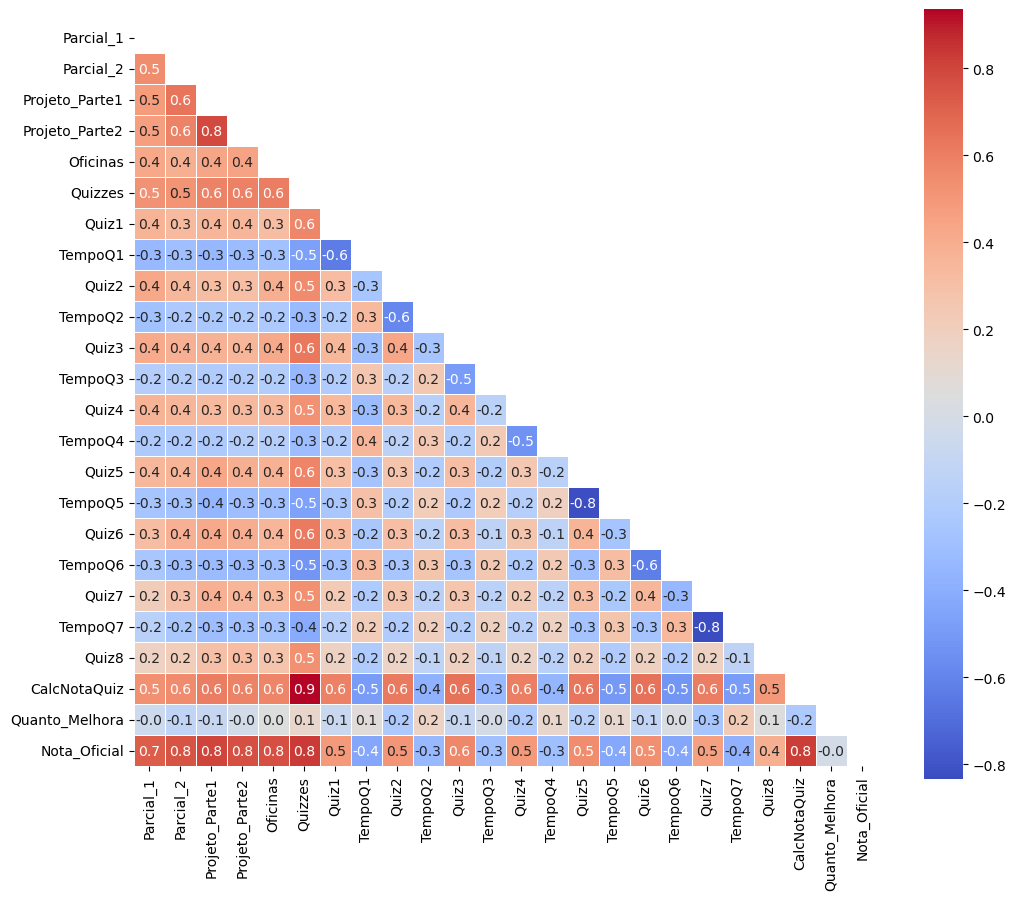

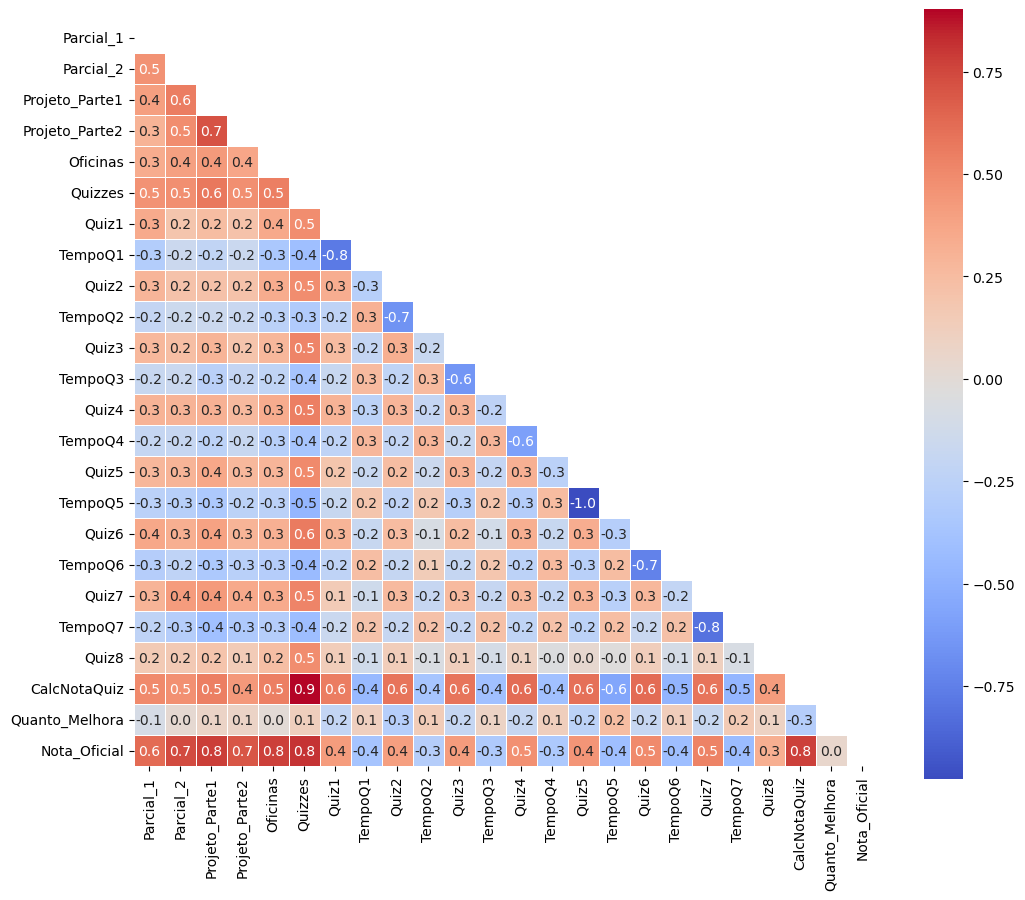

In [149]:
#Identificando colunas numéricas
numerical_cols1 = df1.select_dtypes(include = 'number').columns
numerical_cols2 = df2.select_dtypes(include = 'number').columns

numerical_cols1 = numerical_cols1.drop('Grupo')
numerical_cols2 = numerical_cols2.drop('Grupo')

#crianco a tabela de correlação
correlation1 = df1[numerical_cols1].corr()
correlation2 = df2[numerical_cols2].corr()


# tirando a parte desnecessária que estará no heatmap
mask1 = np.triu(np.ones_like(correlation1, dtype=bool))
mask2 = np.triu(np.ones_like(correlation2, dtype=bool))

# plotando os heatmaps
fig1, ax1 = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation1, annot=True, fmt='.1f', mask=mask1, square=True, linewidths=.5, ax=ax1, cmap='coolwarm')

fig2, ax2 = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation2, annot=True, fmt='.1f', mask=mask1, square=True, linewidths=.5, ax=ax2, cmap='coolwarm')

#### 3.2 Remover colunas redundantes
O intuito dessa célula é remover colunas redundantes do one-hot encoding (baselines) e organizar a ordem das variáveis, garantindo consistência para as análises e modelos.

In [84]:
# Remoção segura: só dropa se existir
baselines = ["STEM_No", "MelhoraNotaQuizzes_False", "Idade_Menor", "Aprovou_Reprovou", 'Genero_Feminino']
drop_list = [c for c in baselines if c in df_onehot.columns]
df_onehot = df_onehot.drop(columns=drop_list)
print("Dummies baseline removidas:", drop_list)
print("df_onehot (após remoção):", df_onehot.shape)

df_onehot = df_onehot[['Tipo_Documento_CC','Tipo_Documento_CE','Tipo_Documento_PP','Tipo_Documento_TI',
                       'Idade_Maior', 'Genero_Masculino', 'STEM_SI', 'MelhoraNotaQuizzes_True', 'Aprovou_Aprovou']]


Dummies baseline removidas: ['STEM_No', 'MelhoraNotaQuizzes_False', 'Idade_Menor', 'Aprovou_Reprovou', 'Genero_Feminino']
df_onehot (após remoção): (1375, 37)


#### 3.3 Aprovados e reprovados por grupo STEM
O intuito dessa célula é gerar um gráfico de barras comparando a quantidade de alunos aprovados e reprovados entre os grupos STEM e não-STEM.

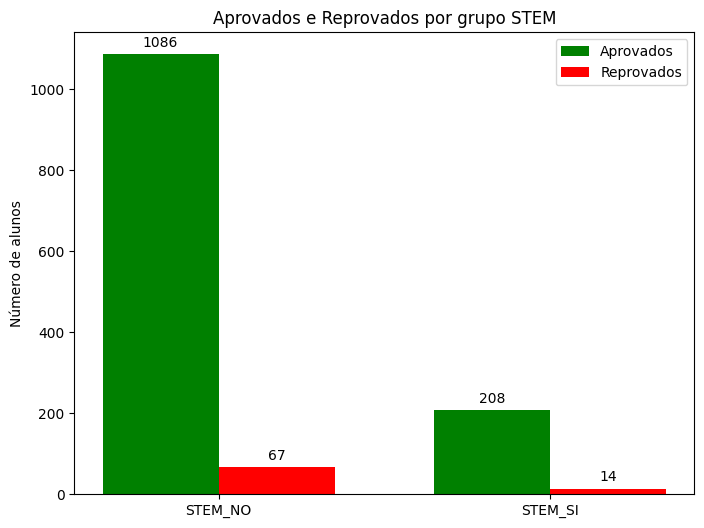

In [151]:


sumario = df_onehot.groupby('STEM_SI')['Aprovou_Aprovou'].value_counts().unstack(fill_value=0)

labels = ['STEM_NO', 'STEM_SI']
aprovados = sumario[1].values
reprovados = sumario[0].values
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8,6))

# Barras lado a lado
rects1 = ax.bar(x - width/2, aprovados, width, label='Aprovados', color='green')
rects2 = ax.bar(x + width/2, reprovados, width, label='Reprovados', color='red')

# Adicionar números em cima de cada barra
ax.bar_label(rects1, padding=3)  # padding é o espaço entre a barra e o número
ax.bar_label(rects2, padding=3)

# Labels e título
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Número de alunos')
ax.set_title('Aprovados e Reprovados por grupo STEM')
ax.legend()

plt.show()



#### 3.4 Alunos aprovados e reprovados, separados por gênero.
O intuito dessa célula é gerar um gráfico de barras comparando a quantidade de alunos aprovados e reprovados, separados por gênero.

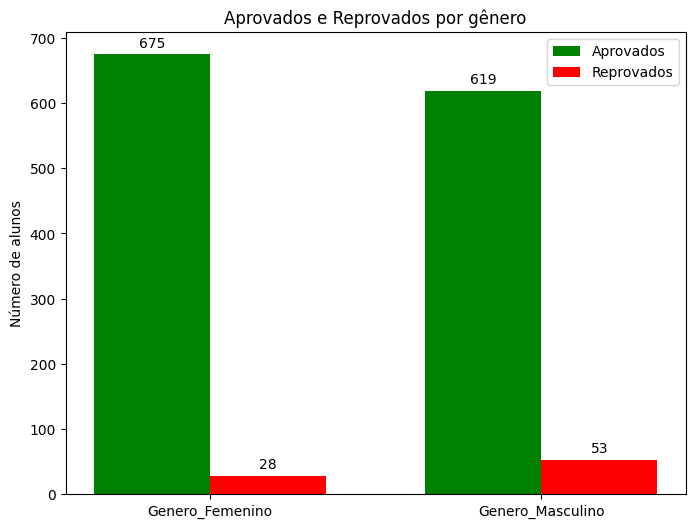

In [152]:

sumario = df_onehot.groupby('Genero_Masculino')['Aprovou_Aprovou'].value_counts().unstack(fill_value=0)

labels = ['Genero_Femenino', 'Genero_Masculino']
aprovados = sumario[1].values
reprovados = sumario[0].values
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))

# Barras lado a lado
rects1 = ax.bar(x - width/2, aprovados, width, label='Aprovados', color='green')
rects2 = ax.bar(x + width/2, reprovados, width, label='Reprovados', color='red')

# Adicionar números em cima de cada barra
ax.bar_label(rects1, padding=3)  # padding é o espaço entre a barra e o número
ax.bar_label(rects2, padding=3)

# Labels e título
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Número de alunos')
ax.set_title('Aprovados e Reprovados por gênero')
ax.legend()

plt.show()


#### 3.5 Distribuição das notas por situação de aprovação
O intuito dessa célula é criar gráficos de dispersão (scatterplots) que mostram a relação entre cada nota (parciais, projetos e oficinas) e o resultado final do aluno (aprovado ou reprovado).

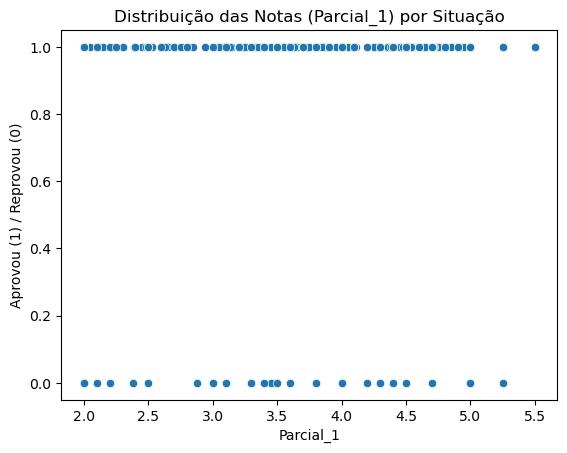

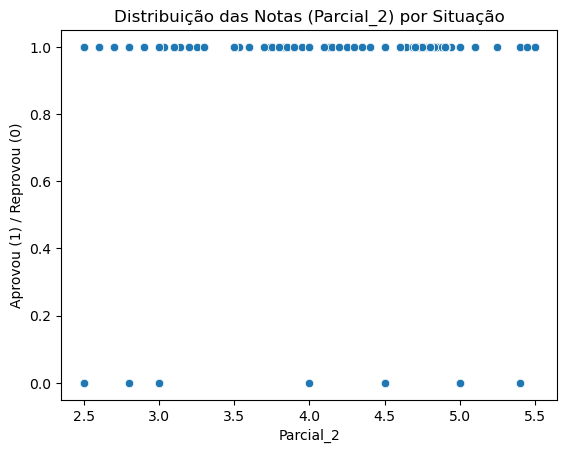

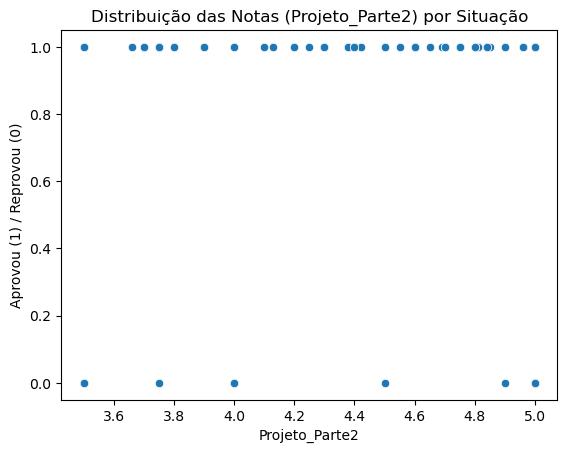

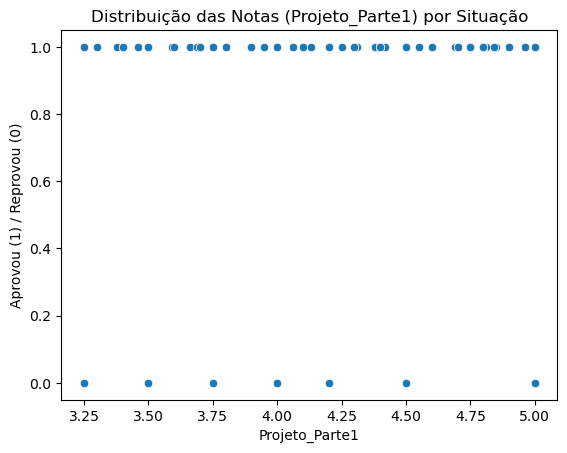

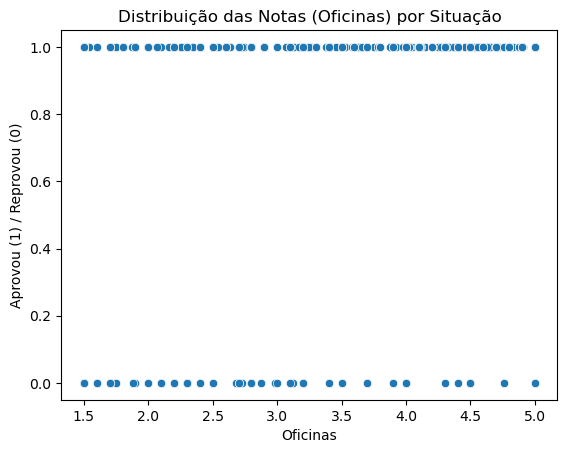

In [153]:
# notas = ['Parcial_1','Parcial_2','Projeto_Parte2','Projeto_Parte1','Oficinas']

# for n in notas:
#     sns.scatterplot(x=df_onehot[n], y='Aprovou_Aprovou', data=df_onehot)
#     plt.title('Distribuição das Notas por Situação')
#     plt.show()
    

#### 3.6 Estatísticas descritivas das variáveis de interesse
O intuito dessa célula é selecionar as colunas principais de desempenho (quizzes, tempos, projetos, oficinas e parciais) e gerar uma tabela descritiva com medidas estatísticas, permitindo uma visão geral dos dados.

In [85]:
# seleciona todas as colunas de interesse
colunas = [
    "Quiz1", "TempoQ1", "Quiz2", "TempoQ2", "Quiz3", "TempoQ3", 
    "Quiz4", "TempoQ4", "Quiz5", "TempoQ5", "Quiz6", "TempoQ6", 
    "Quiz7", "TempoQ7", "Quiz8", "Nota_Oficial", 
    "Projeto_Parte1", "Projeto_Parte2", "Quanto_Melhora", "Oficinas", "Parcial_1",
    "Parcial_2"
]

# gera tabela descritiva
desc_tabela = df_consolidado[colunas].describe().T  # Transpõe para variáveis ficarem como linhas



,count,mean,std,min,25%,50%,75%,max
Quiz1,1375.0,4.405589,0.921258,1.875,3.75,5.0000,5.000000,5.000000
TempoQ1,1375.0,172.202182,92.458930,33.000,100.00,151.0000,225.000000,412.500000
Quiz2,1375.0,4.045862,1.107395,1.100,3.44,4.3800,5.000000,5.000000
TempoQ2,1375.0,214.387273,115.084657,24.000,126.00,186.0000,285.000000,523.500000
Quiz3,1375.0,4.239091,1.047018,1.875,3.75,5.0000,5.000000,5.000000
TempoQ3,1374.0,221.238719,110.757096,32.000,137.00,199.0000,287.750000,513.250000
Quiz4,1375.0,3.757120,1.452105,0.000,2.81,3.7500,5.000000,5.000000
TempoQ4,1375.0,238.324455,119.801302,30.000,149.50,219.0000,313.000000,557.875000
Quiz5,1375.0,4.815578,0.319977,4.225,4.69,5.0000,5.000000,5.000000
TempoQ5,1375.0,145.069818,171.925293,2.000,5.00,87.0000,218.000000,537.500000


#### 3.7 Distribuição das notas por avaliação
O intuito dessa célula é gerar histogramas das notas de quizzes, projetos, oficinas e nota oficial, destacando as médias e medianas em cada gráfico, para facilitar a comparação da distribuição de desempenho entre os alunos.

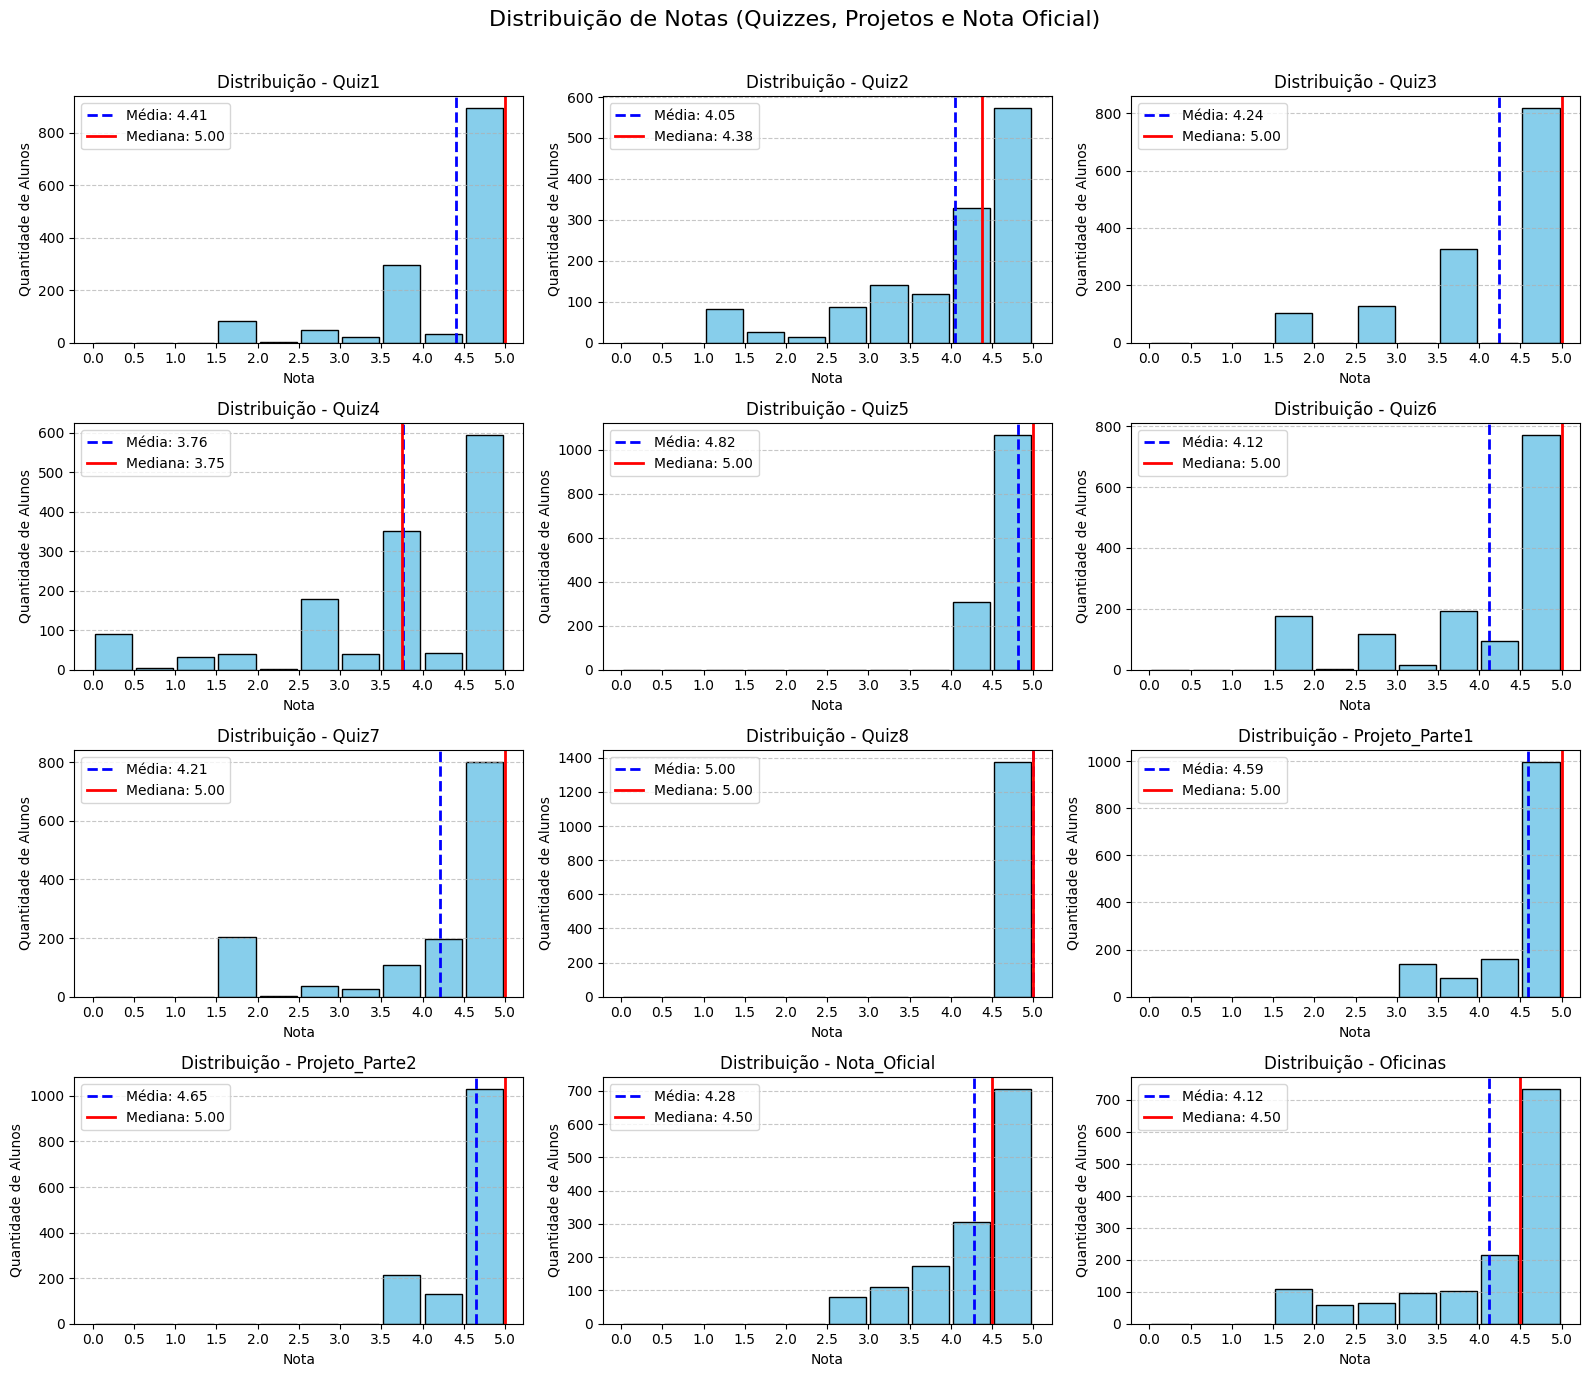

In [155]:
# Lista de quizzes + projetos + nota oficial
avaliacoes = [f"Quiz{i}" for i in range(1, 9)] + ["Projeto_Parte1", "Projeto_Parte2", "Nota_Oficial", "Oficinas"]

# Definir bins de 0 até 5 com passo 0.25
bins = np.arange(0, 5.25, 0.5)  # inclui 5

# Criar grade de subplots (4x3 para 11 avaliações)
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, avaliacao in enumerate(avaliacoes):
    ax = axes[i]
    
    # Histograma com bins fixos
    ax.hist(df_consolidado[avaliacao], bins=bins, color="skyblue", edgecolor="black", rwidth=0.9)
    
    # Calcular média e mediana
    media = df_consolidado[avaliacao].mean()
    mediana = df_consolidado[avaliacao].median()
    
    # Linhas de média e mediana
    ax.axvline(media, color="blue", linestyle="--", linewidth=2, label=f"Média: {media:.2f}")
    ax.axvline(mediana, color="red", linestyle="-", linewidth=2, label=f"Mediana: {mediana:.2f}")
    
    # Configurações do gráfico
    ax.set_title(f"Distribuição - {avaliacao}")
    ax.set_xlabel("Nota")
    ax.set_ylabel("Quantidade de Alunos")
    ax.set_xticks(bins)  # força ticks de 0 a 5 de 0.25 em 0.25
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend()

# Remove eixos extras se sobrar espaços (caso 12 slots, mas só 11 avaliações)
for j in range(len(avaliacoes), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição de Notas (Quizzes, Projetos e Nota Oficial)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



#### 3.8 Teste de normalidade da nota dos quizzes
O intuito dessa célula é verificar se a variável CalcNotaQuiz segue uma distribuição normal utilizando o teste de Shapiro-Wilk, auxiliando na escolha de métodos estatísticos adequados para análises posteriores.

In [156]:
# Testes de normalidade das variáveis "CalcNotaQuiz", "Talleres", "Calificación_Oficial"
# Testando normalidade para "CalcNotaQuiz" via Shapiro-Wilk
from scipy.stats import shapiro

dados = df_consolidado['CalcNotaQuiz'].dropna()

stat, p = shapiro(dados)

print('H0: Os dados seguem uma distribuição normal')
print('H1: Os dados não seguem uma distribuição normal')
print("Estatística W:", stat)
print("p-valor:", p)

if p > 0.05:
    print("Não rejeitamos H0: os dados seguem uma distribuição normal.")
else:
    print("Rejeitamos H0: os dados não seguem uma distribuição normal.")

H0: Os dados seguem uma distribuição normal
H1: Os dados não seguem uma distribuição normal
Estatística W: 0.9158549463812558
p-valor: 5.737420736467878e-27
Rejeitamos H0: os dados não seguem uma distribuição normal.


#### 3.9 Teste de normalidade das oficinas

O intuito dessa célula é verificar se a variável Oficinas (Talleres) segue uma distribuição normal utilizando o teste de Shapiro-Wilk, para orientar análises estatísticas apropriadas.

In [157]:
# Testando normalidade para "Oficinas" (Talleres) via Shapiro-Wilk

from scipy.stats import shapiro

dados = df_consolidado['Oficinas'].dropna()

stat, p = shapiro(dados)

print('H0: Os dados seguem uma distribuição normal')
print('H1: Os dados não seguem uma distribuição normal')
print("Estatística W:", stat)
print("p-valor:", p)

if p > 0.05:
    print("Não rejeitamos H0: os dados seguem uma distribuição normal.")
else:
    print("Rejeitamos H0: os dados não seguem uma distribuição normal.")

H0: Os dados seguem uma distribuição normal
H1: Os dados não seguem uma distribuição normal
Estatística W: 0.7847014498757214
p-valor: 3.386401173855684e-39
Rejeitamos H0: os dados não seguem uma distribuição normal.


#### 3.10 Teste de normalidade da nota oficial
O intuito dessa célula é verificar se a variável Nota_Oficial (Calificación_Oficial) segue uma distribuição normal utilizando o teste de Shapiro-Wilk, ajudando a definir quais testes estatísticos aplicar nas análises posteriores.

In [158]:
# Testando normalidade para "Nota_Oficial" (Calificación_Oficial) via Shapiro-Wilk
from scipy.stats import shapiro

dados = df_consolidado['Nota_Oficial'].dropna()

stat, p = shapiro(dados)

print('H0: Os dados seguem uma distribuição normal')
print('H1: Os dados não seguem uma distribuição normal')
print("Estatística W:", stat)
print("p-valor:", p)


if p > 0.05:
    print("Não rejeitamos H0: os dados seguem uma distribuição normal.")
else:
    print("Rejeitamos H0: os dados não seguem uma distribuição normal.")

H0: Os dados seguem uma distribuição normal
H1: Os dados não seguem uma distribuição normal
Estatística W: 0.8781437508785028
p-valor: 1.6769770433793975e-31
Rejeitamos H0: os dados não seguem uma distribuição normal.


#### 3.11 Escalonamento das variáveis
O intuito dessa célula é padronizar e normalizar as variáveis Nota_Oficial, CalcNotaQuiz e Oficinas utilizando StandardScaler (Z-score) e MinMaxScaler [0,1], garantindo que todas as variáveis fiquem na mesma escala para análises e modelagem.

In [86]:
# Escalonamento das variáveis testadas
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Criando cópia para não sobrescrever
df_scaled = df_consolidado.copy()

# ----------------------
# Padronização (Z-score)
# ----------------------
scaler_standard = StandardScaler()

# Calificacion_Oficial
df_scaled["Nota_Oficial"] = scaler_standard.fit_transform(
    df_consolidado[["Nota_Oficial"]]
)

# CalcNotaQuiz
df_scaled["CalcNotaQuiz_scaled"] = scaler_standard.fit_transform(
    df_consolidado[["CalcNotaQuiz"]]
)

# ----------------------
# Min-Max [0,1]
# ----------------------
scaler_minmax = MinMaxScaler()

# Talleres
df_scaled["Oficinas"] = scaler_minmax.fit_transform(
    df_consolidado[["Oficinas"]]
)


#### 3.12 Análise visual das oficinas
O intuito dessa célula é criar um gráfico múltiplo com histograma e violin plot da variável Oficinas, permitindo analisar a distribuição, a densidade, a presença de outliers e a média das notas de forma visual e detalhada.

In [160]:
# Criar subplots com 2 linhas e 1 coluna para acomodar o histograma e o violin plot
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=('Histograma de Oficinas', 'Violin Plot de Oficinas'), # Títulos para cada subplot
    vertical_spacing=0.15  # Aumentar o espaço vertical entre os subplots para evitar sobreposição de títulos/rótulos
)

# Adicionar o histograma para a coluna 'Oficinas'
fig.add_trace(
    go.Histogram(
        x=df_consolidado['Oficinas'], # Dados para o histograma
        nbinsx=30, # Número de bins no histograma
        name='', # Nome da trace (não exibido com showlegend=False)
        marker=dict(
            color='#004066', # Cor das barras do histograma
            opacity=0.8, # Opacidade das barras
            line=dict(color='black', width=1) # Adiciona borda preta às barras
        )
    ),
    row=1, col=1 # Posicionar no primeiro subplot (primeira linha, primeira coluna)
)

# Adicionar o violin plot para a coluna 'Oficinas'
fig.add_trace(
    go.Violin(
        y=df_consolidado['Oficinas'], # Dados para o violin plot
        name='', # Nome da trace
        marker_color='#004066', # Cor do violin plot
        opacity=0.8, # Opacidade
        box_visible=True, # Mostrar box plot dentro do violin plot
        meanline_visible=True # Mostrar linha da média
    ),
    row=2, col=1 # Posicionar no segundo subplot (segunda linha, primeira coluna)
)


# Atualizar configurações gerais de layout do gráfico
fig.update_layout(
    title_text="Análise de Oficinas - Multiplot", # Título principal do gráfico
    height=900, # Altura do gráfico em pixels
    showlegend=False, # Não mostrar a legenda
    plot_bgcolor='white', # Cor de fundo da área de plotagem
    paper_bgcolor='white', # Cor de fundo do papel (área fora da plotagem)
    font=dict(family="Arial"), # Fonte do texto do gráfico
    margin=dict(t=80) # Aumentar margem superior para o título principal não ficar muito próximo do topo
)

# Atualizar layout dos eixos do histograma
fig.update_xaxes(title_text="Nota de Oficinas", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo X
fig.update_yaxes(title_text="Frequência", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y

# Atualizar layout dos eixos do violin plot
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Remover rótulo do eixo X para evitar redundância
fig.update_yaxes(title_text="Nota de Oficinas", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y


fig.update_layout(height=700, width=1000) # Ajustar altura e largura finais do gráfico
# Mostrar o gráfico
fig.show(renderer="browser")

#### 3.13 Análise visual da nota oficial
O intuito dessa célula é criar um gráfico múltiplo com histograma e violin plot da variável Nota_Oficial, permitindo visualizar a distribuição das notas, densidade, presença de outliers e posição da média de forma detalhada.

In [161]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Criar subplots com 2 linhas e 1 coluna para acomodar o histograma e o violin plot
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=('Histograma de Nota Oficial', 'Violin Plot de Nota Oficial'), # Títulos para cada subplot
    vertical_spacing=0.15 # Aumentar o espaço vertical entre os subplots para evitar sobreposição de títulos/rótulos
)

# Adicionar o histograma para a coluna 'Nota_Oficial'
fig.add_trace(
    go.Histogram(
        x=df_consolidado['Nota_Oficial'], # Dados para o histograma
        nbinsx=30, # Número de bins no histograma
        name='', # Nome da trace (não exibido com showlegend=False)
        marker=dict(
            color='#004066', # Cor das barras do histograma
            opacity=0.8, # Opacidade das barras
            line=dict(color='black', width=1) # Adiciona borda preta às barras
        )
    ),
    row=1, col=1 # Posicionar no primeiro subplot (primeira linha, primeira coluna)
)

# Adicionar o violin plot para a coluna 'Nota_Oficial'
fig.add_trace(
    go.Violin(
        y=df_consolidado['Nota_Oficial'], # Dados para o violin plot
        name='', # Nome da trace
        marker_color='#004066', # Cor do violin plot
        opacity=0.8, # Opacidade
        box_visible=True, # Mostrar box plot dentro do violin plot
        meanline_visible=True # Mostrar linha da média
    ),
    row=2, col=1 # Posicionar no segundo subplot (segunda linha, primeira coluna)
)


# Atualizar configurações gerais de layout do gráfico
fig.update_layout(
    title_text="Análise de Nota Oficial - Multiplot", # Título principal do gráfico
    height=900, # Altura do gráfico em pixels
    showlegend=False, # Não mostrar a legenda
    plot_bgcolor='white', # Cor de fundo da área de plotagem
    paper_bgcolor='white', # Cor de fundo do papel (área fora da plotagem)
    font=dict(family="Arial"), # Fonte do texto do gráfico
    margin=dict(t=80) # Aumentar margem superior para o título principal não ficar muito próximo do topo
)

# Atualizar layout dos eixos do histograma
fig.update_xaxes(title_text="Nota Oficial", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo X
fig.update_yaxes(title_text="Frequência", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y

# Atualizar layout dos eixos do violin plot
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Remover rótulo do eixo X para evitar redundância
fig.update_yaxes(title_text="Nota Oficial", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y


fig.update_layout(height=700, width=1000) # Ajustar altura e largura finais do gráfico
# Mostrar o gráfico
fig.show(renderer="browser")

Histograma e Violin Plot [CalcNotaQuiz]

#### 3.14 Análise visual das notas dos quizzes
O intuito dessa célula é criar um gráfico múltiplo com histograma e violin plot da variável CalcNotaQuiz, permitindo observar a distribuição das notas, densidade, presença de outliers e posição da média de forma detalhada.

In [162]:
# Criar subplots com 2 linhas e 1 coluna para acomodar o histograma e o violin plot
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=('Histograma de CalcNotaQuiz', 'Violin Plot de CalcNotaQuiz'), # Títulos para cada subplot
    vertical_spacing=0.15 # Aumentar o espaço vertical entre os subplots para evitar sobreposição de títulos/rótulos
)

# Adicionar o histograma para a coluna 'CalcNotaQuiz'
fig.add_trace(
    go.Histogram(
        x=df_consolidado['CalcNotaQuiz'], # Dados para o histograma
        nbinsx=30, # Número de bins no histograma
        name='', # Nome da trace (não exibido com showlegend=False)
        marker=dict(
            color='#004066', # Cor das barras do histograma
            opacity=0.8, # Opacidade das barras
            line=dict(color='black', width=1) # Adiciona borda preta às barras
        )
    ),
    row=1, col=1 # Posicionar no primeiro subplot (primeira linha, primeira coluna)
)

# Adicionar o violin plot para a coluna 'CalcNotaQuiz'
fig.add_trace(
    go.Violin(
        y=df_consolidado['CalcNotaQuiz'], # Dados para o violin plot
        name='', # Nome da trace
        marker_color='#004066', # Cor do violin plot
        opacity=0.8, # Opacidade
        box_visible=True, # Mostrar box plot dentro do violin plot
        meanline_visible=True # Mostrar linha da média
    ),
    row=2, col=1 # Posicionar no segundo subplot (segunda linha, primeira coluna)
)


# Atualizar configurações gerais de layout do gráfico
fig.update_layout(
    title_text="Análise de CalcNotaQuiz - Multiplot", # Título principal do gráfico
    height=900, # Altura do gráfico em pixels
    showlegend=False, # Não mostrar a legenda
    plot_bgcolor='white', # Cor de fundo da área de plotagem
    paper_bgcolor='white', # Cor de fundo do papel (área fora da plotagem)
    font=dict(family="Arial"), # Fonte do texto do gráfico
    margin=dict(t=80) # Aumentar margem superior para o título principal não ficar muito próximo do topo
)

# Atualizar layout dos eixos do histograma
fig.update_xaxes(title_text="Nota CalcNotaQuiz", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo X
fig.update_yaxes(title_text="Frequência", row=1, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y

# Atualizar layout dos eixos do violin plot
fig.update_xaxes(title_text="", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Remover rótulo do eixo X para evitar redundância
fig.update_yaxes(title_text="Nota CalcNotaQuiz", row=2, col=1, gridcolor='lightgray', zerolinecolor='lightgray') # Rótulo do eixo Y


fig.update_layout(height=700, width=1000) # Ajustar altura e largura finais do gráfico
# Mostrar o gráfico
fig.show(renderer="browser")

#### 3.15 Escalonamento de quizzes e tempos
O intuito dessa célula é normalizar as notas dos quizzes e os tempos de resolução utilizando MinMaxScaler [0,1], criando um DataFrame final apenas com as variáveis escalonadas para análises e modelagem subsequentes.

In [87]:
quizzes = ['Quiz1','Quiz2','Quiz3','Quiz4','Quiz5','Quiz6','Quiz7', "Parcial_1", "Parcial_2"]

for q in quizzes:
    df_scaled[q] = scaler_minmax.fit_transform(
        df_consolidado[[q]]
    )

tempo = ['TempoQ1','TempoQ2','TempoQ3','TempoQ4','TempoQ5','TempoQ6','TempoQ7']

for t in tempo:
    df_scaled[t] = scaler_minmax.fit_transform(
        df_consolidado[[t]]
    )

#Seleciona apenas as variáveis escalonadas para que depois se crie o df final
df_scaled = df_scaled[['Quiz1','Quiz2','Quiz3','Quiz4','Quiz5','Quiz6','Quiz7','TempoQ1','TempoQ2','TempoQ3',
                       'TempoQ4','TempoQ5','TempoQ6','TempoQ7',"Nota_Oficial","CalcNotaQuiz_scaled","Oficinas","Projeto_Parte1", "Projeto_Parte2","Parcial_1",
    "Parcial_2"]]

   Quiz1     Quiz2  Quiz3  Quiz4  Quiz5  Quiz6  Quiz7   TempoQ1   TempoQ2  \
0    1.0  0.000000    0.0    0.5    0.0   0.00    0.0  0.426877  1.000000   
1    1.0  1.000000    0.6    0.0    0.0   0.20    0.0  0.553360  0.612613   
2    0.0  0.000000    0.2    0.0    0.0   0.28    0.0  1.000000  1.000000   
3    0.6  0.000000    0.6    0.5    0.0   1.00    1.0  0.316206  1.000000   
4    1.0  0.679487    0.6    0.5    0.0   0.00    0.0  0.318841  0.276276   

    TempoQ3   TempoQ4  TempoQ5   TempoQ6   TempoQ7  Nota_Oficial  \
0  1.000000  0.452759      1.0  1.000000  1.000000     -2.329760   
1  0.534026  1.000000      1.0  0.181985  1.000000     -1.887512   
2  0.114286  1.000000      1.0  0.130515  1.000000     -2.550883   
3  0.280519  0.212171      1.0  0.562500  0.160072     -0.118522   
4  0.132987  0.318257      1.0  1.000000  1.000000     -2.550883   

   CalcNotaQuiz_scaled  Oficinas  
0            -2.769320  0.857143  
1            -1.861098  0.166786  
2            -2.769320 

#### 3.16 Análise visual das oficinas pós-escalonamento
O intuito dessa célula é gerar histogramas e violin plots da variável Oficinas após escalonamento, permitindo observar a distribuição e densidade das notas normalizadas, bem como a presença de outliers.

In [88]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Subplots: histograma + violin
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Histograma de Oficinas (pós-escalonamento)', 'Violin Plot de Oficinas (pós-escalonamento)'),
    vertical_spacing=0.15
)

# Histograma
fig.add_trace(
    go.Histogram(
        x=df_scaled['Oficinas'],
        nbinsx=30,
        marker=dict(
            color='#004066',
            opacity=0.8,
            line=dict(color='black', width=1)
        ),
        name=''
    ),
    row=1, col=1
)

# Violin
fig.add_trace(
    go.Violin(
        y=df_scaled['Oficinas'],
        name='',
        marker_color='#004066',
        opacity=0.8,
        box_visible=True,
        meanline_visible=True
    ),
    row=2, col=1
)

fig.update_layout(
    showlegend=False,
    bargap=0.05,
    width=900, height=700,
    title_text='Oficinas — Pós-escalonamento'
)
fig.update_xaxes(title_text='Oficinas (escalonado?)', row=1, col=1)
fig.update_yaxes(title_text='Frequência', row=1, col=1)
fig.update_yaxes(title_text='Distribuição', row=2, col=1)

fig.show()


#### 2.7 Dividindo o modelo para 3 fases da previsão

In [89]:
df_final["Reprovou"] = df_final["Aprovou_Aprovou"].apply(lambda x: 0 if x == 1 else 1)
df_final.drop('Aprovou_Aprovou', axis  = 1, inplace = True)

In [11]:
df_final1 = df_final[['Genero_Masculino','STEM_SI',  'Quiz1', 'Quiz2', 'Quiz3', 'TempoQ1', 'TempoQ2', 'TempoQ3', 'Reprovou']]

df_final2 = df_final[['Genero_Masculino','STEM_SI', 'Quiz1', 'Quiz2', 'Quiz3','Quiz4', 'TempoQ1', 'TempoQ2', 'TempoQ3','TempoQ4', 'Parcial_1', 'Reprovou']]

df_final3 = df_final[['Genero_Masculino','STEM_SI', 'Quiz1', 'Quiz2', 'Quiz3','Quiz4','Quiz5', 'Quiz6', 'TempoQ1', 'TempoQ2', 'TempoQ3','TempoQ4', 'TempoQ5', 'TempoQ6','Parcial_1' , 'Reprovou']]

#### 3.17 Análise visual da nota oficial pós-escalonamento
O intuito dessa célula é gerar histogramas e violin plots da variável Nota_Oficial após padronização (Z-score), permitindo analisar a distribuição, densidade e presença de outliers das notas normalizadas.

In [91]:
df1.to_csv('dados/dados_bruto_sem1.csv', index=False)
df2.to_csv('dados/dados_bruto_sem2.csv', index=False)
df_consolidado.to_csv('dados/dados_consolidado.csv', index=False)
df_onehot.to_csv('dados/dados_onehot.csv', index=False)
df_scaled.to_csv('dados/dados_escalado.csv', index=False)
df_final.to_csv('dados/dados_modelo.csv', index=False)
df_final1.to_csv('dados/dados_modelo1.csv', index=False)
df_final2.to_csv('dados/dados_modelo2.csv', index=False)
df_final3.to_csv('dados/dados_modelo3.csv', index=False)

#### 3.2 Visualização dos dados exportados em tabelas

In [92]:
df1.head()

,Periodo,Grupo,Horario,Tipo_Documento,Idade,Genero,Nome_Programa_Academico,STEM,Parcial_1,Parcial_2,...,TempoQ6,Data_Quiz7,Quiz7,TempoQ7,Quiz8,CalcNotaQuiz,MelhoraNotaQuizzes,Quanto_Melhora,Nota_Oficial,Aprovou
0,2023-1,11,Viernes de 03:00PM a 06:00PM,CC,Maior,Feminino,Comunicacao Social,No,4.20,0.0,...,600,NaN,0.0,600,5,1.56250,True,2.73750,2.7,Reprovou
1,2023-1,16,Jueves de 06:00PM a 09:00PM,CC,Maior,Feminino,Direito,No,3.75,5.0,...,133,NaN,0.0,600,5,2.65625,True,2.34375,3.0,Aprovou
2,2023-1,11,Viernes de 03:00PM a 06:00PM,CC,Maior,Masculino,Engenharia Civil,SI,0.00,0.0,...,105,NaN,0.0,600,5,1.28125,True,2.01875,1.6,Reprovou
3,2023-1,7,Jueves de 12:00PM a 03:00PM,CC,Maior,Feminino,Administracao de Negocios,No,2.80,3.5,...,340,4 de May de 2023 13:37,5.0,124,5,3.12500,True,1.87500,4.2,Aprovou
4,2023-1,11,Viernes de 03:00PM a 06:00PM,TI,Menor,Masculino,Engenharia Civil,SI,1.80,0.0,...,600,NaN,0.0,600,5,2.50000,True,1.90000,2.5,Reprovou


In [93]:
df2.head()

,Periodo,Grupo,Horario,Tipo_Documento,Idade,Genero,Nome_Programa_Academico,STEM,Parcial_1,Parcial_2,...,TempoQ6,Data_Quiz7,Quiz7,TempoQ7,Quiz8,CalcNotaQuiz,MelhoraNotaQuizzes,Quanto_Melhora,Nota_Oficial,Aprovou
0,2023-2,60,Jueves de 09:00AM a 12:00PM,CC,Maior,Feminino,Psicologia,No,0.0,0.0,...,600,NaN,0.0,600,5,0.62500,False,0.0,0.1,Reprovou
1,2023-2,49,Jueves de 03:00PM a 06:00PM,TI,Menor,Masculino,Administracao de Negocios,No,0.0,0.0,...,600,NaN,0.0,600,0,0.00000,False,0.0,0.0,Reprovou
2,2023-2,46,Miércoles de 12:00PM a 03:00PM,CC,Maior,Masculino,Negocios Internacionais,No,0.0,0.0,...,600,NaN,0.0,600,0,0.00000,False,0.0,0.0,Reprovou
3,2023-2,60,Jueves de 09:00AM a 12:00PM,CC,Maior,Feminino,Direito,No,0.0,0.0,...,600,NaN,0.0,600,5,2.34375,False,0.0,2.2,Reprovou
4,2023-2,53,Miércoles de 06:00PM a 09:00PM,CC,Maior,Feminino,Administracao de Negocios,No,0.0,0.0,...,600,NaN,0.0,600,0,0.00000,False,0.0,0.0,Reprovou


In [94]:
df_consolidado.head()

,Periodo,Grupo,Horario,Tipo_Documento,Idade,Genero,Nome_Programa_Academico,STEM,Parcial_1,Parcial_2,...,Quiz6,TempoQ6,Quiz7,TempoQ7,Quiz8,CalcNotaQuiz,MelhoraNotaQuizzes,Quanto_Melhora,Nota_Oficial,Aprovou
0,2023-1,11,Viernes de 03:00PM a 06:00PM,CC,Maior,Feminino,Comunicacao Social,No,4.20,2.5,...,1.875,578,1.875,591,5,1.965625,True,0.744531,2.70,Reprovou
1,2023-1,16,Jueves de 06:00PM a 09:00PM,CC,Maior,Feminino,Direito,No,3.75,5.0,...,2.500,133,1.875,591,5,2.656250,True,0.744531,3.00,Aprovou
2,2023-1,11,Viernes de 03:00PM a 06:00PM,CC,Maior,Masculino,Engenharia Civil,SI,2.00,2.5,...,2.750,105,1.875,591,5,1.965625,True,0.744531,2.55,Reprovou
3,2023-1,7,Jueves de 12:00PM a 03:00PM,CC,Maior,Feminino,Administracao de Negocios,No,2.80,3.5,...,5.000,340,5.000,124,5,3.125000,True,0.744531,4.20,Aprovou
4,2023-1,11,Viernes de 03:00PM a 06:00PM,TI,Menor,Masculino,Engenharia Civil,SI,2.00,2.5,...,1.875,578,1.875,591,5,2.500000,True,0.744531,2.55,Reprovou


In [95]:
df_onehot.head()

,Tipo_Documento_CC,Tipo_Documento_CE,Tipo_Documento_PP,Tipo_Documento_TI,Idade_Maior,Genero_Masculino,STEM_SI,MelhoraNotaQuizzes_True,Aprovou_Aprovou
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0


In [96]:
df_scaled.head()

,Quiz1,Quiz2,Quiz3,Quiz4,Quiz5,Quiz6,Quiz7,TempoQ1,TempoQ2,TempoQ3,...,TempoQ5,TempoQ6,TempoQ7,Nota_Oficial,CalcNotaQuiz_scaled,Oficinas,Projeto_Parte1,Projeto_Parte2,Parcial_1,Parcial_2
0,1.0,0.000000,0.0,0.5,0.0,0.00,0.0,0.426877,1.000000,1.000000,...,1.0,1.000000,1.000000,-2.329760,-2.769320,0.857143,3.25,3.5,0.628571,0.000000
1,1.0,1.000000,0.6,0.0,0.0,0.20,0.0,0.553360,0.612613,0.534026,...,1.0,0.181985,1.000000,-1.887512,-1.861098,0.166786,3.25,3.5,0.500000,0.833333
2,0.0,0.000000,0.2,0.0,0.0,0.28,0.0,1.000000,1.000000,0.114286,...,1.0,0.130515,1.000000,-2.550883,-2.769320,0.571429,3.25,3.5,0.000000,0.000000
3,0.6,0.000000,0.6,0.5,0.0,1.00,1.0,0.316206,1.000000,0.280519,...,1.0,0.562500,0.160072,-0.118522,-1.244657,1.000000,3.25,5.0,0.228571,0.333333
4,1.0,0.679487,0.6,0.5,0.0,0.00,0.0,0.318841,0.276276,0.132987,...,1.0,1.000000,1.000000,-2.550883,-2.066578,1.000000,3.25,3.5,0.000000,0.000000
